In [128]:
# Generating 10000 rows of Syntetic data
import pandas as pd
import numpy as np

n=10000
df=pd.DataFrame({"id":range(1,n+1),
                 "age":np.random.randint(18,80,size=n),
                 "Salary":np.random.normal(50000,15000,size=n).round(2),
                 "score":np.random.uniform(0,100,size=n).round(1)})
df["target"]=(((df["age"]>30) & (df["score"]>45))& (df["Salary"]>30000)).astype(int)
df["target"]=df["target"].replace({0:-1})
df["target"].value_counts()
df.head()

,id,age,Salary,score,target
0,1,79,28024.27,41.1,-1
1,2,43,56127.98,35.1,-1
2,3,26,16001.69,26.9,-1
3,4,40,68945.57,7.4,-1
4,5,27,47010.64,71.7,-1


In [129]:
# train-test-split
X=df[["age","Salary","score"]]
Y=df["target"]
rng=np.random.default_rng(42)
def train_test_split(X,Y,n):
    indices=np.arange(n)
    rng.shuffle(indices)
    x_shuffled=X.iloc[indices]
    y_shuffled=Y.iloc[indices]
    n_test=int(n*.2)
    n_train=n-n_test

    x_train=x_shuffled[:n_train]
    y_train=y_shuffled[:n_train]

    x_test=x_shuffled[n_train:]
    y_test=y_shuffled[n_train:]
    return x_train,x_test,y_train,y_test
x_train,x_test,y_train,y_test=train_test_split(X,Y,n)
x_train_np = x_train.to_numpy()
x_test_np = x_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

In [130]:
# Standardisation
class ZScore:
    def __init__(self):
        self.mean=None
        self.dev=None
    def fit(self,X_train):
        self.mean=np.mean(X_train,axis=0)
        self.dev=np.std(X_train,axis=0)
        return self
    def transform(self,X):
        return (X-self.mean)/self.dev
    def fit_tranform(self,X):
        self.fit(X)
        return self.transform(X)

In [131]:
def sigmoid(z):
    z=np.clip(z,-500,500)
    return np.where(z>=0,1/(1+np.exp(-z)),np.exp(z)/(1+np.exp(z)))
def log_loss(X,y,w):
    margin=y*np.dot(X,w.T)
    return np.mean(np.logaddexp(0,-margin))
def L2(w):
    return 0.5*np.dot(w[1:],w[1:])
def gradient(X,y,w):
     margin=y*np.dot(X,w.T)
     return -(np.dot(X.T,y*(sigmoid(-margin))))/X.shape[0]


In [132]:
scaler=ZScore()

x_train_scaled=scaler.fit_tranform(x_train_np)
x_test_scaled=scaler.transform(x_test_np)
x_train_scaled=np.c_[np.ones(x_train_scaled.shape[0]),x_train_scaled]
x_test_scaled=np.c_[np.ones(x_test_scaled.shape[0]),x_test_scaled]
lr=0.1
lambda_val=0.01
loss_hist=[]
w=np.zeros(x_train_scaled.shape[1])
max_epochs=1000
prev_loss=float("inf")
epoch=0
tolerance=1e-5
while epoch<max_epochs:
    loss=log_loss(x_train_scaled,y_train_np,w)+lambda_val*L2(w)
    grad=gradient(x_train_scaled,y_train_np,w)+lambda_val * np.concatenate(([0], w[1:]))
    w=w-lr*grad
    loss_hist.append(loss)
    if abs(prev_loss-loss)<tolerance:
        break
    prev_loss=loss
    epoch+=1
print(epoch)

365


In [133]:
def predict(X,w):
    scores=np.dot(X,w.T)
    return np.where(scores>=0,1,-1)
y_pred=predict(x_test_scaled,w)
accuracy=np.mean(y_pred==y_test_np)
print(accuracy*100)

84.55


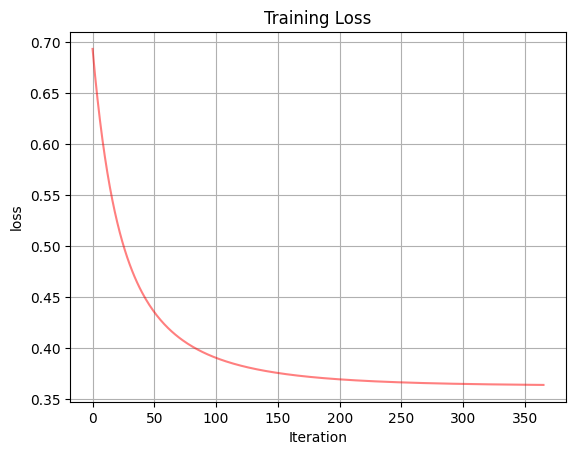

In [134]:
import matplotlib.pyplot as plt
plt.plot(loss_hist,alpha=0.5,label='raw',color="red")
plt.xlabel("Iteration")
plt.ylabel("loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()